# Signal Evaluation Fallback

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from autoencoder_utils import *

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
model, result, rmse = conditional_factor_model()
result['bucket'] = pd.qcut(result.prediction.rank(method='first'), 5, labels=False) + 1
quality = result.groupby('bucket').target.agg(['mean', 'std', 'count']).reset_index()
quality.to_csv(OUTPUT / 'conditional_signal_quality.csv', index=False)
quality

/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


,bucket,mean,std,count
0,1,0.0074,0.0224,48
1,2,0.0009,0.0204,48
2,3,-0.0011,0.0214,48
3,4,-0.0020,0.0205,48
4,5,-0.0015,0.0228,48


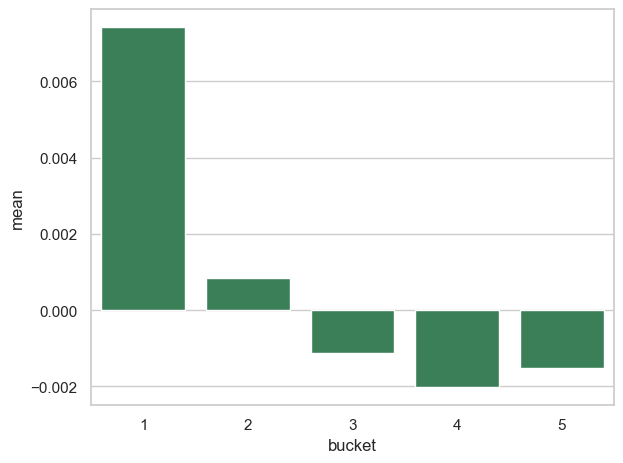

In [3]:
sns.barplot(data=quality, x='bucket', y='mean', color='seagreen')
plt.tight_layout()